In [2]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()
import os
OPENAI_API_KEY=os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_API_KEY"]=OPENAI_API_KEY
openai_model=ChatOpenAI(model="gpt-4o")
openai_model.invoke("hi")

from langgraph.graph import StateGraph,MessagesState, START, END
from langgraph.graph.message import add_messages
from typing import Annotated, Literal, TypedDict
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode

import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
os.environ["TAVILY_API_KEY"]=TAVILY_API_KEY

In [4]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

In [5]:
tavily=TavilySearchResults()

C:\Users\behur\AppData\Local\Temp\ipykernel_23884\1844490623.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily=TavilySearchResults()


In [6]:
tools = [tavily]

In [7]:
llm_with_tools = openai_model.bind_tools(tools)

In [8]:
def ai_assistant(state: AgentState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [9]:
memory = MemorySaver()

In [10]:
graph_builder = StateGraph(AgentState)
graph_builder.add_node("ai_assistant", ai_assistant)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [11]:
graph_builder.add_edge(START, "ai_assistant")

graph_builder.add_conditional_edges(
    "ai_assistant",
    tools_condition,
)
graph_builder.add_edge("tools", "ai_assistant")

In [12]:
app2 = graph_builder.compile(
    checkpointer=memory,
    # This is new!
    interrupt_before=["tools"],
    # Note: can also interrupt __after__ tools, if desired.
    # interrupt_after=["tools"]
)

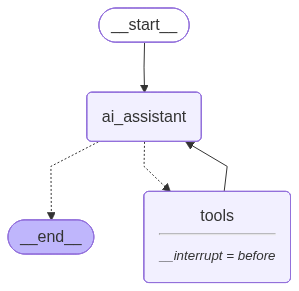

In [13]:
from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

In [14]:
user_input = "what is current a capital of india?"
config = {"configurable": {"thread_id": "1"}}

In [15]:
events = app2.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

In [16]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

what is current a capital of india?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_zLQDZn1iu9YBPhEOVyry4zo9)
 Call ID: call_zLQDZn1iu9YBPhEOVyry4zo9
  Args:
    query: current capital of India


In [17]:
snapshot = app2.get_state(config)

In [18]:
snapshot.next

('tools',)

In [19]:
last_message=snapshot.values["messages"][-1]

In [20]:
last_message.tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'current capital of India'},
  'id': 'call_zLQDZn1iu9YBPhEOVyry4zo9',
  'type': 'tool_call'}]

In [21]:
events = app2.stream(None, config, stream_mode="values")

In [22]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_zLQDZn1iu9YBPhEOVyry4zo9)
 Call ID: call_zLQDZn1iu9YBPhEOVyry4zo9
  Args:
    query: current capital of India
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "States and Capitals of India –List of Indian States & UTs (2026)", "url": "https://store.pw.live/blogs/ssc-exams/states-and-capitals-of-india-list?srsltid=AfmBOorVr1Vzd1v6u0ItcPjMtAl4KJ5m0ifqLYs-DUfPvVYJrsqKfQCF", "content": "|  |  |  |\n --- \n| S.No. | State | Capital |\n| 1 | Andhra Pradesh | Amaravati |\n| 2 | Arunachal Pradesh | Itanagar |\n| 3 | Assam | Dispur |\n| 4 | Bihar | Patna |\n| 5 | Chhattisgarh | Raipur |\n| 6 | Goa | Panaji |\n| 7 | Gujarat | Gandhinagar |\n| 8 | Haryana | Chandigarh |\n| 9 | Himachal Pradesh | Shimla |\n| 10 | Jharkhand | Ranchi |\n| 11 | Karnataka | Bengaluru |\n| 12 | Kerala | Thiruvananthap

In [23]:
user_input = "what is a weather there?"

config = {"configurable": {"thread_id": "1"}}

In [24]:
events = app2.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

In [25]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

what is a weather there?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_TP27i3E1LcY56lajUHI4LYmB)
 Call ID: call_TP27i3E1LcY56lajUHI4LYmB
  Args:
    query: current weather in New Delhi


In [26]:
snapshot = app2.get_state(config)

In [27]:
snapshot.next

('tools',)

In [28]:
last_message=snapshot.values["messages"][-1]

In [29]:
last_message.tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'current weather in New Delhi'},
  'id': 'call_TP27i3E1LcY56lajUHI4LYmB',
  'type': 'tool_call'}]

In [30]:
events = app2.stream(None, config, stream_mode="values")

In [31]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_TP27i3E1LcY56lajUHI4LYmB)
 Call ID: call_TP27i3E1LcY56lajUHI4LYmB
  Args:
    query: current weather in New Delhi
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Delhi weather in May 2026 | Delhi 14 day weather", "url": "https://www.weather25.com/asia/india/delhi?page=month&month=May", "content": "weather25.com\nSearch\nweather in India\nRemove from your favorite locations\nAdd to my locations\nShare\nweather in India\n\n# Delhi weather in May 2026\n\nPartly cloudy\nClear\nPartly cloudy\nClear\nClear\nClear\nClear\nClear\nClear\nClear\nClear\nClear\nClear\nClear\n\n## The average weather in Delhi in May\n\nThe temperatures in Delhi during May are extremely high, between 32°C and hot as 43°C, drinking water regularly is advisable.\n\nYou can expect a few rainy days in Delhi during Ma

In [32]:
app2.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='what is current a capital of india?', additional_kwargs={}, response_metadata={}, id='0d934e1c-1ce5-433f-9cd9-982b8ae480db'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 87, 'total_tokens': 108, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_14b1a3bf2b', 'id': 'chatcmpl-DfimVdPeW9jhu8oUyfqOq1mDETvUd', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e2ae2-acca-7951-ac88-fba33a2f08c7-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'current capital of India'}, 'id': 'call_zLQDZn1iu9YBPhEOVyry4zo9', 'type': 'tool_call'}], invalid_to

In [33]:
snapshot=app2.get_state(config)

In [34]:
snapshot.next

()

In [35]:
user_input = "give me the recent news there?"

config = {"configurable": {"thread_id": "1"}}

In [36]:
events = app2.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

In [37]:
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

give me the recent news there?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_gtwzEVN5MngSzf671WgAThyn)
 Call ID: call_gtwzEVN5MngSzf671WgAThyn
  Args:
    query: recent news New Delhi


In [38]:
snapshot=app2.get_state(config)

In [40]:
snapshot.next

('tools',)

In [41]:

current_message = snapshot.values["messages"][-1]

In [42]:
current_message.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_gtwzEVN5MngSzf671WgAThyn)
 Call ID: call_gtwzEVN5MngSzf671WgAThyn
  Args:
    query: recent news New Delhi


In [43]:
tool_call_id = current_message.tool_calls[0]["id"] 

In [44]:
from langchain_core.messages import AIMessage, ToolMessage

In [46]:
answer = "it is just related to heatwave which is happening on daily basis in delhi"

In [47]:
new_messages = [
    ToolMessage(content=answer, tool_call_id=tool_call_id),
    AIMessage(content=answer),
]

In [48]:
app2.update_state(
    config,
    {"messages": new_messages},
)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1503dd-c268-69ff-800c-6e6461ceb54a'}}

In [49]:
print(app2.get_state(config).values["messages"][-1:])

[AIMessage(content='it is just related to heatwave which is happening on daily basis in delhi', additional_kwargs={}, response_metadata={}, id='59ea1dcf-f2ee-45a5-88bf-9685e2010568', tool_calls=[], invalid_tool_calls=[])]
